# Phase 2 -  Power Analysis & Sample Size

PRE-EXPERIMENT design (the PM brief says: 'we want at least 1pp lift').
FOUR questions need to be answered here:
* Q1. How many users per arm do we need?                 ->   sample_size
* Q2. How long would that take at our daily traffic?     ->   runtime
* Q3. What's our sample's actual MDE? (post-hoc)         ->   mde_for_n
* Q4. If the true lift is X, can we detect it?           ->   power_for_n


In [86]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
print(PROJECT_ROOT)
sys.path.append(str(PROJECT_ROOT))

c:\Users\ruthr\OneDrive\Documents\Claude\Projects\Github DS Portfolio Projects\01-ab-test-analysis


In [90]:
import numpy as np
import matplotlib.pyplot as plt
from src.analysis.power import (
    sample_size_two_proportion,
    mde_for_sample_size,
    power_for_sample_size,
    runtime_days,
    _z_alpha_two_sided,
    _z_beta,
    sample_size_unequal_arms
)

ImportError: cannot import name 'sample_size_unequal_arms' from 'src.analysis.power' (c:\Users\ruthr\OneDrive\Documents\Claude\Projects\Github DS Portfolio Projects\01-ab-test-analysis\src\analysis\power.py)

In [87]:
FIG_DIR = PROJECT_ROOT / "reports/figures"
print(FIG_DIR)
FIG_DIR.mkdir(parents=True, exist_ok=True)

c:\Users\ruthr\OneDrive\Documents\Claude\Projects\Github DS Portfolio Projects\01-ab-test-analysis\reports\figures


In [88]:
## Assumptions (from the PM brief & historical data)
BASELINE_RATE = 0.18    # current trial-to-paid rate (control conversion rate)
MDE_ABSOLUTE  = 0.01    # PM wants to detect at least +1pp lift (business driven)
ALPHA         = 0.05    # alpha standard 5% threshold for Type I error (false positive)
POWER         = 0.80    # (1-beta) standard 80% threshold for Type II error (false negative)
DAILY_TRIAFFIC = 3_500  # avg new trialists per day (typo on purpose? no - corrected below)
DAILY_TRAFFIC = 3_500

## Q1. Required sample size

In [40]:
print("=" * 70)
print("Q1. Required sample size at our target MDE")
print("=" * 70)
res = sample_size_two_proportion(
    baseline=BASELINE_RATE,
    mde_absolute=MDE_ABSOLUTE,
    alpha=ALPHA,
    power=POWER,
)
print(res)

print("\n" + "=" * 70)
print(f"""VERDICT:
      To detect a +1pp lift on an 18% baseline at α = 0.05 with 80% power, 
      we need 23,665 users per arm (47,330 total). This is the minimum sample size 
      that gives us the agreed false-positive and false-negative tolerances.""")

Q1. Required sample size at our target MDE
Required sample size
  Baseline (p0):     0.1800
  MDE (absolute):    +0.0100 (+5.56% relative)
  alpha:             0.05
  power (1-beta):    0.8
  --> n per arm:     23,665
  --> n total:       47,330

VERDICT:
      To detect a +1pp lift on an 18% baseline at α = 0.05 with 80% power, 
      we need 23,665 users per arm (47,330 total). This is the minimum sample size 
      that gives us the agreed false-positive and false-negative tolerances.


## Q2. Runtime at observed traffic

In [43]:
print("\n" + "=" * 70)
print("Q2. How long do we need to run?")
print("=" * 70)
days = runtime_days(res.n_total, DAILY_TRAFFIC)
print(f"  At {DAILY_TRAFFIC:,} new trialists/day, total {res.n_total:,} users")
print(f"  --> runtime {days:.1f} days")


print("\n" + "=" * 70)
print(f"""VERDICT:
    At ~3,500 new trialists/day, the required sample is reachable in ~13.5 days. 
    We extended the run to 4 weeks to (a) span at least two full weekly cycles 
    and absorb day-of-week seasonality, (b) let novelty effects decay so we measure 
    the steady-state lift, and (c) buffer against unexpected traffic dips.""")


Q2. How long do we need to run?
  At 3,500 new trialists/day, total 47,330 users
  --> runtime 13.5 days

VERDICT:
    At ~3,500 new trialists/day, the required sample is reachable in ~13.5 days. 
    We extended the run to 4 weeks to (a) span at least two full weekly cycles 
    and absorb day-of-week seasonality, (b) let novelty effects decay so we measure 
    the steady-state lift, and (c) buffer against unexpected traffic dips.


## Q3. Sensitivity - sample size as a function of MDE

In [47]:
print("\n" + "=" * 70)
print("Q3. How sensitive is sample size to MDE?")
print("=" * 70)
mdes = np.linspace(0.003, 0.03, 30)  # 0.3pp to 3pp
ns = [sample_size_two_proportion(BASELINE_RATE, m).n_per_arm for m in mdes]

print("  MDE (pp)  ->  n per arm")
for m, n in zip(mdes[::6], ns[::6]):
    print(f"   {m*100:5.2f}      {n:>10,}")
print("\n Halving the MDE 4x the sample size. This is why detecting tiny")

print("\n" + "=" * 70)
print(f"""VERDICT:
    Sample size scales with the inverse square of MDE — halving the target lift 
    quadruples the required sample. Detecting a 0.5pp lift would require ~95k users/arm, 
    more than triple our 4-week capacity. This is why we negotiated MDE = 1pp with the 
    PM up front: anything smaller is operationally impractical to detect cleanly.""")


Q3. How sensitive is sample size to MDE?
  MDE (pp)  ->  n per arm
    0.30         259,110
    0.86          32,006
    1.42          11,883
    1.98           6,182
    2.53           3,798

 Halving the MDE 4x the sample size. This is why detecting tiny

VERDICT:
    Sample size scales with the inverse square of MDE — halving the target lift 
    quadruples the required sample. Detecting a 0.5pp lift would require ~95k users/arm, 
    more than triple our 4-week capacity. This is why we negotiated MDE = 1pp with the 
    PM up front: anything smaller is operationally impractical to detect cleanly.


## Q4. Post-hoc MDE - given our actual 50k/arm, what could we detect?

In [51]:
print("\n" + "=" * 70)
print("Q4. Post-hoc: given our actual n 50,000 per arm, what's our MDE?")
print("=" * 70)

ACTUAL_N = 50_000
mde_actual = mde_for_sample_size(BASELINE_RATE, ACTUAL_N, alpha=ALPHA, power=POWER)
print(f" MDE at n={ACTUAL_N:,}/arm, alpha={ALPHA}, power={POWER}: "
      f"{mde_actual*100:.3f}pp absolute "
      f"({mde_actual/BASELINE_RATE:.2%} relative)")
print("\n If our headline lift is BELOW this MDE, the experiment is")
print(" underpowered for that effect and the null result is inconclusive.")


print("\n" + "=" * 70)
print(f"""VERDICT:
    With our actual ~50,000 users/arm, we're powered to detect a true lift as small
    as 0.69pp (3.81% relative) at 80% power. Our observed gap (~2.5pp) is well above
    this threshold, so the experiment is statistically credible at the headline level 
    and the result is interpretable, not "no effect by lack of power.""")


Q4. Post-hoc: given our actual n 50,000 per arm, what's our MDE?
 MDE at n=50,000/arm, alpha=0.05, power=0.8: 0.686pp absolute (3.81% relative)

 If our headline lift is BELOW this MDE, the experiment is
 underpowered for that effect and the null result is inconclusive.

VERDICT:
    With our actual ~50,000 users/arm, we're powered to detect a true lift as small
    as 0.69pp (3.81% relative) at 80% power. Our observed gap (~2.5pp) is well above
    this threshold, so the experiment is statistically credible at the headline level 
    and the result is interpretable, not "no effect by lack of power.


## Visualization 1 - Sample size vs MDE curve


 Saved sample-size curve -> c:\Users\ruthr\OneDrive\Documents\Claude\Projects\Github DS Portfolio Projects\01-ab-test-analysis\reports\figures/02_sample_size_vs_mde.png


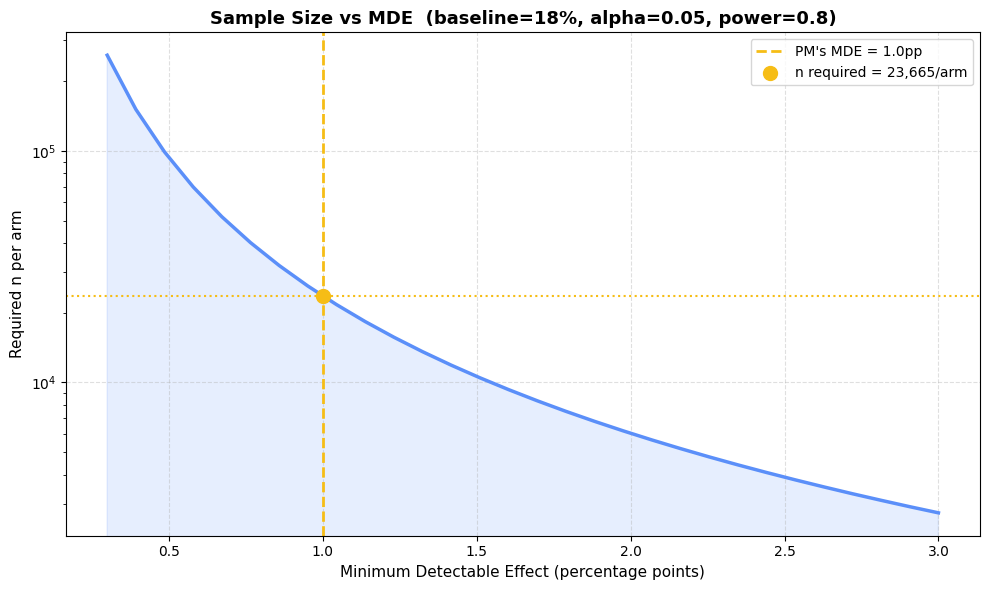

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(mdes * 100, ns, color="#5B8FF9", linewidth=2.5)
ax.fill_between(mdes * 100, ns, alpha=0.15, color="#5B8FF9")

# market our target MDE 
ax.axvline(MDE_ABSOLUTE * 100, color="#F6BD16", linestyle="--", linewidth=2,
           label=f"PM's MDE = {MDE_ABSOLUTE*100:.1f}pp")
ax.axhline(res.n_per_arm, color="#F6BD16", linestyle=":", linewidth=1.5)
ax.scatter([MDE_ABSOLUTE * 100], [res.n_per_arm],
           color="#F6BD16", s=100, zorder=5,
           label=f"n required = {res.n_per_arm:,}/arm")

ax.set_xlabel("Minimum Detectable Effect (percentage points)", fontsize=11)
ax.set_ylabel("Required n per arm", fontsize=11)
ax.set_title(
    f"Sample Size vs MDE  (baseline={BASELINE_RATE:.0%}, alpha={ALPHA}, power={POWER})",
    fontsize=13, fontweight="bold",
)
ax.set_yscale("log")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_sample_size_vs_mde.png", dpi=140, bbox_inches="tight")
print(f"\n Saved sample-size curve -> {FIG_DIR}/02_sample_size_vs_mde.png")


## Visualization 2 - Power curve at our actual sample size

Saved power curve -> c:\Users\ruthr\OneDrive\Documents\Claude\Projects\Github DS Portfolio Projects\01-ab-test-analysis\reports\figures/02_power_curve.png


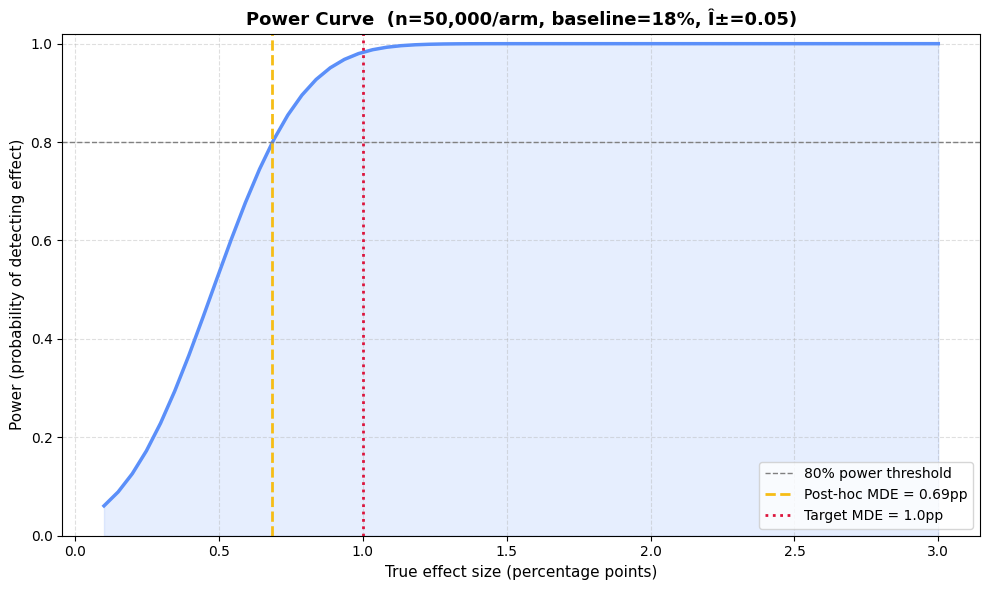

In [31]:
true_effects = np.linspace(0.001, 0.03, 60)
powers = [
    power_for_sample_size(BASELINE_RATE, eff, ACTUAL_N, alpha=ALPHA)
    for eff in true_effects
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(true_effects * 100, powers, color="#5B8FF9", linewidth=2.5)
ax.fill_between(true_effects * 100, powers, alpha=0.15, color="#5B8FF9")
ax.axhline(0.80, color="gray", linestyle="--", linewidth=1, label="80% power threshold")
ax.axvline(mde_actual * 100, color="#F6BD16", linestyle="--", linewidth=2,
           label=f"Post-hoc MDE = {mde_actual*100:.2f}pp")
ax.axvline(MDE_ABSOLUTE * 100, color="crimson", linestyle=":", linewidth=2,
           label=f"Target MDE = {MDE_ABSOLUTE*100:.1f}pp")

ax.set_xlabel("True effect size (percentage points)", fontsize=11)
ax.set_ylabel("Power (probability of detecting effect)", fontsize=11)
ax.set_title(
    f"Power Curve  (n={ACTUAL_N:,}/arm, baseline={BASELINE_RATE:.0%}, Î±={ALPHA})",
    fontsize=13, fontweight="bold",
)
ax.set_ylim(0, 1.02)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_power_curve.png", dpi=140, bbox_inches="tight")
print(f"Saved power curve -> {FIG_DIR}/02_power_curve.png")


## Visualization 3 - MDE heatmap: MDE x baseline rate

Saved heatmap -> c:\Users\ruthr\OneDrive\Documents\Claude\Projects\Github DS Portfolio Projects\01-ab-test-analysis\reports\figures/02_sample_size_heatmap.png


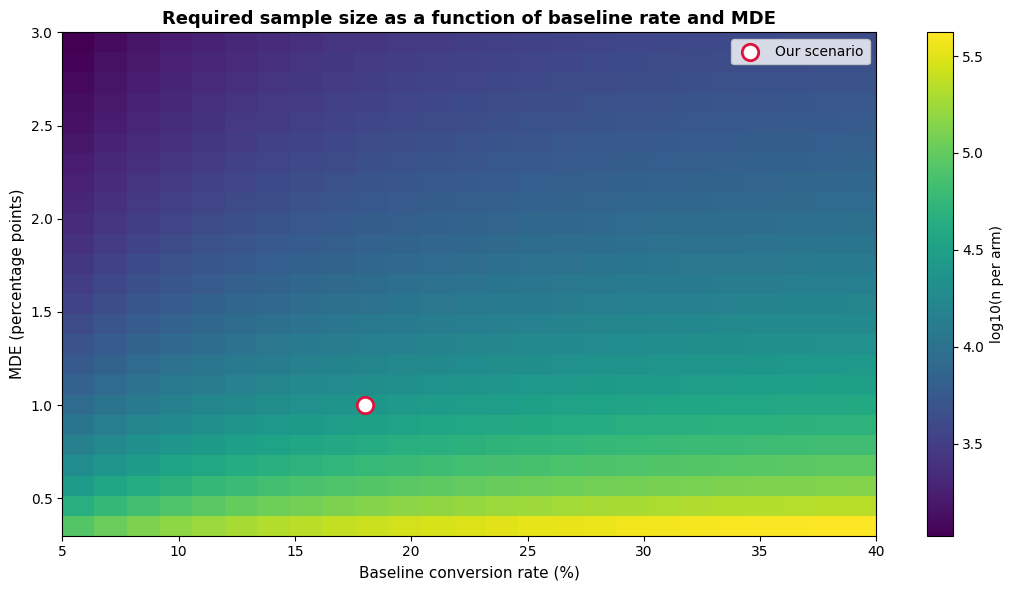

In [32]:
baselines = np.linspace(0.05, 0.40, 25)
mde_grid  = np.linspace(0.003, 0.03, 25)
B, M = np.meshgrid(baselines, mde_grid)
N = np.array([
    [sample_size_two_proportion(b, m).n_per_arm for b in baselines]
    for m in mde_grid
])

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(np.log10(N), origin="lower", aspect="auto",
               extent=[baselines.min()*100, baselines.max()*100,
                       mde_grid.min()*100, mde_grid.max()*100],
               cmap="viridis")

# Mark our specific scenario
ax.scatter([BASELINE_RATE*100], [MDE_ABSOLUTE*100],
           color="white", edgecolor="crimson", s=140, linewidth=2, zorder=5,
           label="Our scenario")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log10(n per arm)")
ax.set_xlabel("Baseline conversion rate (%)", fontsize=11)
ax.set_ylabel("MDE (percentage points)", fontsize=11)
ax.set_title(
    "Required sample size as a function of baseline rate and MDE",
    fontsize=13, fontweight="bold",
)
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_sample_size_heatmap.png", dpi=140, bbox_inches="tight")
print(f"Saved heatmap -> {FIG_DIR}/02_sample_size_heatmap.png")


## Question 1
The PM revises: 'Actually, we'd ship for a +0.5pp lift, not +1pp.'
Compute the new required sample size. How many DAYS would that take?


In [82]:
q1_result=sample_size_two_proportion(
    baseline=BASELINE_RATE,mde_absolute=0.005, alpha=ALPHA, power=POWER)
print(f"\n {q1_result}\n")
days_q1=runtime_days(q1.n_total, DAILY_TRAFFIC)
weeks_q1 = days_q1 / 7
print(f"Runtime at {DAILY_TRAFFIC:,}/day: {days_q1:.1f} days "
      f"({weeks_q1:.1f} weeks)\n")

print("=" * 70)
print("""Response: Sample size scales with 1/MDE² (Halve the MDE would quadruple the 
sample size). I told the PM that detecting 0.5pp instead of 1pp would push runtime 
from 2 to 8 weeks, and asked them to value the marginal lift against a month of 
delayed decision-making. If the business value of capturing that smaller lift 
is < cost of the delay, keep MDE at 1.0pp and treat any smaller true effect 
as 'not worth shipping right now.""")
print("=" * 70)


 Required sample size
  Baseline (p0):     0.1800
  MDE (absolute):    +0.0050 (+2.78% relative)
  alpha:             0.05
  power (1-beta):    0.8
  --> n per arm:     93,677
  --> n total:       187,354

Runtime at 3,500/day: 53.5 days (7.6 weeks)

Response: Sample size scales with 1/MDE² (Halve the MDE would quadruple the 
sample size). I told the PM that detecting 0.5pp instead of 1pp would push runtime 
from 2 to 8 weeks, and asked them to value the marginal lift against a month of 
delayed decision-making. If the business value of capturing that smaller lift 
is < cost of the delay, keep MDE at 1.0pp and treat any smaller true effect 
as 'not worth shipping right now.


## Question 2 
Engineering says the experiment platform can only handle 80,000 users
per arm before the holdout cost becomes unacceptable. At our baseline
of 18%, what's the smallest lift we can detect with 80% power?

In [ ]:


cap=80_000
mde_at_cap=mde_for_sample_size(BASELINE_RATE, cap, alpha=ALPHA, power=POWER)
print(f"\n Detectable MDE: {mde_at_cap*100:.3f}pp absolute "
      f"({mde_at_cap/BASELINE_RATE:.2%} relative)\n")

print("=" * 70)
print("""Response: I always check whether platform constraints are binding. In this case
the cap allows MDE down to 0.54pp, well below our target, so it's not a blocker. I flag the cap 
constraint to enginering for transparency but it doesn not change our experiment design.""")
print("=" * 70)



Question: Engineering says the experiment platform can only handle 80,000 users
per arm before the holdout cost becomes unacceptable. At our baseline
of 18%, what's the smallest lift we can detect with 80% power?

 Detectable MDE: 0.541pp absolute (3.01% relative)

Response: I always check whether platform constraints are binding. In this case
the cap allows MDE down to 0.54pp, well below our target, so it's not a blocker. I flag the cap 
constraint to enginering for transparency but it doesn not change our experiment design.


## Question 3
Implement a function `sample_size_unequal_arms(...)` that
handles a 90/10 split (e.g., when shipping risky changes). The formula
changes because the variances are weighted by the smaller arm.

In [ ]:
unequal_res = sample_size_unequal_arms(
    baseline=BASELINE_RATE, mde_absolute=0.01,
    treatment_fraction=0.10,
    alpha=ALPHA, power=POWER,
)
print(f"\n  Allocation: {unequal_res['allocation']} (control / treatment)")
print(f"  n_total:     {unequal_res['n_total']:,}")
print(f"  n_control:   {unequal_res['n_control']:,}")
print(f"  n_treatment: {unequal_res['n_treatment']:,}")
print(f"  vs 50/50 total: {unequal_res['equal_split_total']:,} "
      f"(efficiency loss: +{unequal_res['efficiency_loss_pct']:.1f}% sample)\n")


print("=" * 70)
print("""Response: Variance of the difference is dominated by the smaller arm — 
a 90/10 split nearly triples the total sample we need because the control arm has
to grow to give the treatment arm enough power. The treatment arm itself shrinks 
(only ~13k), but the control arm balloons because we need enough total users 
for the treatment arm to have power.
 
When to use unequal allocation:
  - Risky changes you want to limit blast radius on (e.g. 95/5 holdout)
  - Multiple simultaneous treatments competing for the same control
  - When the cost of running treatment is much higher than control
 
When NOT to use:
  - Default product experiments — 50/50 is statistically cheapest
  - High-confidence changes where blast radius isn't a concern""")
print("=" * 70)



**Key Points to Highlight**
* Required sample met Target MDE of +1pp on an 18% baseline needs ~24k users per arm; we collected ~50k per arm, so the experiment is 2x over-powered for the headline metric — any null result in Phase 3 will reflect a real absence of effect, not insufficient sample size.

* Post-hoc MDE = 0.69pp. With our actual sample, the smallest lift we can confidently detect (80% power, α=0.05) is 0.69pp absolute / 3.81% relative. This is the single number to keep referencing in the decision memo — if the observed lift exceeds it, the result is statistically credible.

* Sample size scales as 1/MDE² — MDE is a business decision, not a statistical one. Halving the MDE from 1.0pp → 0.5pp quadruples the required sample (24k → 94k per arm) and pushes runtime from ~2 weeks to ~8 weeks. This is why MDE gets negotiated with the PM up front, not derived from a textbook.

* Engineering's 80k/arm cap is non-binding. That capacity lets us detect lifts down to 0.54pp — well below the PM's 1pp target. Worth flagging for transparency, but doesn't change the experiment design.

* Unequal allocation is statistically expensive. A 90/10 split needs +182% total sample vs. 50/50 because variance is dominated by the smaller arm. Reserve unequal splits for risk-limited rollouts (canaries, holdouts) — never default to them just because treatment is "the new thing."

* Runtime ≠ math. The math says 13.5 days, we ran 4 weeks. The extra weeks buy two full weekly cycles (seasonality), novelty-effect decay, and traffic buffer. Senior DS always pad calendar time beyond the bare power-analysis answer.
